[CHECK 1] Device : cpu

[CHECK 2] SwitchTab embedding lookup: 364,997 entries
[CHECK 2] Note: embeddings from Phase1=200ep, Phase2=50ep
[CHECK 2] Label lookup: 364,997 entries
[CHECK 2] IDpol split — train:49,974, val:10,709, test:10,709
[CHECK 2] Raw feature lookup: 364,997 entries

[CHECK 2] SwitchTab Standalone loaded from nb04:
  AUC-ROC : 0.7668
  F1@0.5  : 0.3570
  Best F1 : 0.3822

[CHECK 3] Building LightGBM flat datasets...
[CHECK 3] Train:255,241 | Val:55,001 | Test:54,755
[CHECK 3] X_raw shape : (255241, 5)
[CHECK 3] X_stab shape: (255241, 128)
[CHECK 3] Positive rate — train:12.66%, test:12.79%

[LightGBM] Training LightGBM-Raw...
[100]	valid_0's auc: 0.766656
[LightGBM] LightGBM-Raw — AUC:0.7687, F1@0.5:0.3608, BestF1:0.3796 (thr=0.606)

[LightGBM] Training LightGBM-STab...
[LightGBM] LightGBM-STab — AUC:0.7675, F1@0.5:0.0000, BestF1:0.3797 (thr=0.360)

[CHECK 5] Building LSTM sequence datasets...
[CHECK 5] Raw  seqs — train:49,974, val:10,709, test:10,709
[CHECK 5] STab s

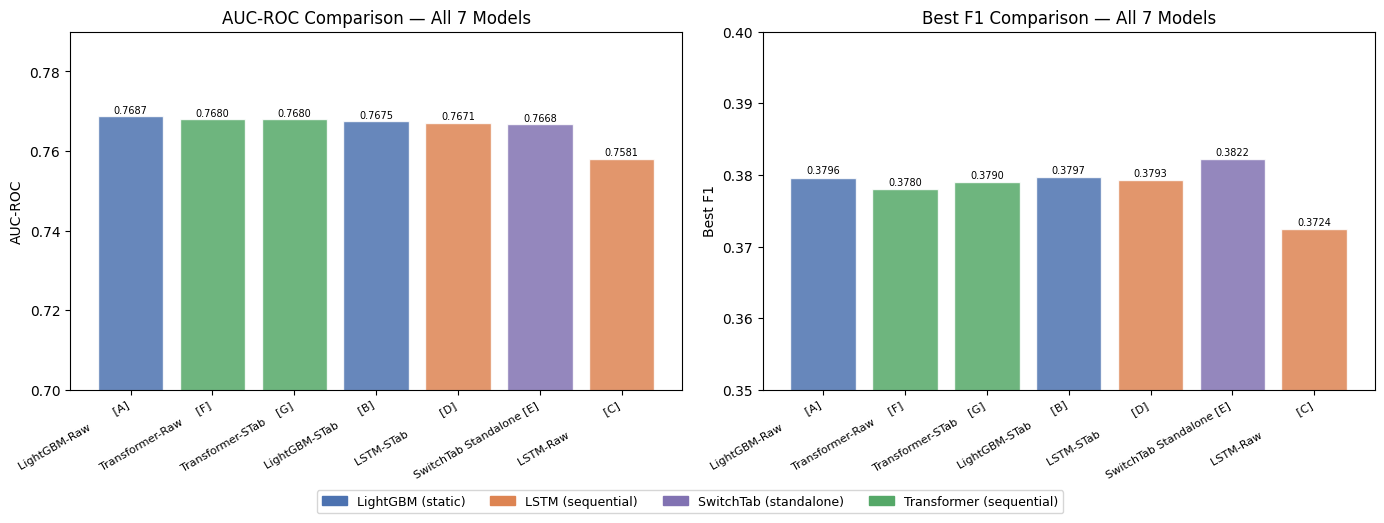

[CHECK 10] Saved: data/results/06_model_comparison.png
[CHECK 11] Saved: data/results/06_comparison_table.csv


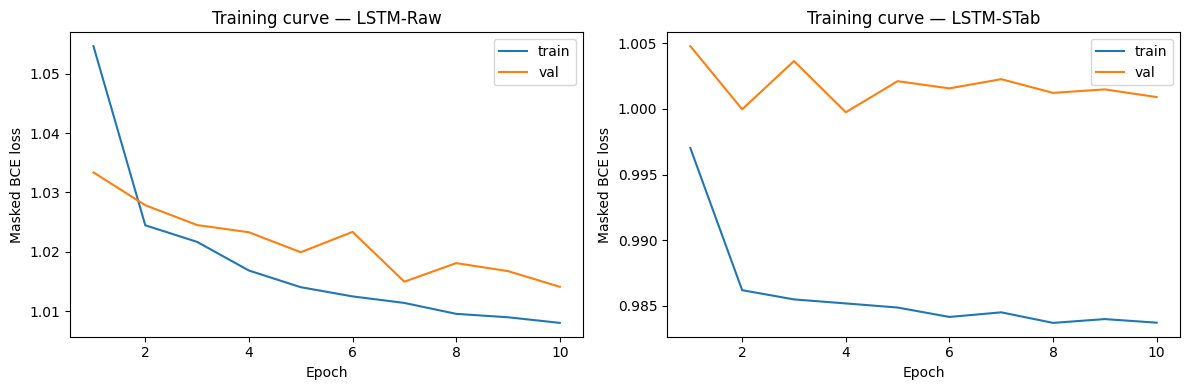

[CHECK 12] Saved: data/results/06_lstm_curves.png

===== Notebook 06 Final Summary =====
Total models compared: 7
  [A] LightGBM-Raw        (static, raw features)
  [B] LightGBM-STab       (static, SwitchTab emb)
  [C] LSTM-Raw            (sequential, raw features)
  [D] LSTM-STab           (sequential, SwitchTab emb)
  [E] SwitchTab Standalone (Phase1=200ep + Phase2=50ep)
  [F] Transformer-Raw     (sequential, raw features, nb03)
  [G] Transformer-STab    (sequential, SwitchTab emb, nb05)

Ranked by AUC-ROC:
  1. LightGBM-Raw        [A]        AUC=0.7687  BestF1=0.3796
  2. Transformer-Raw     [F]        AUC=0.7680  BestF1=0.3780
  3. Transformer-STab    [G]        AUC=0.7680  BestF1=0.3790
  4. LightGBM-STab       [B]        AUC=0.7675  BestF1=0.3797
  5. LSTM-STab           [D]        AUC=0.7671  BestF1=0.3793
  6. SwitchTab Standalone [E]       AUC=0.7668  BestF1=0.3822
  7. LSTM-Raw            [C]        AUC=0.7581  BestF1=0.3724

Best AUC  : 0.7687 — LightGBM-Raw        [A]
Best 

In [2]:
# ============================================================
# Notebook    : 06_baseline_models.ipynb
# Description : Baseline comparison models for the SwitchTab
#               longitudinal risk prediction framework.
#               Seven models trained and evaluated:
#
#               [A] LightGBM-Raw        : raw 5 features, static
#               [B] LightGBM-STab       : SwitchTab 128-dim, static
#               [C] LSTM-Raw            : raw 5-feature sequences
#               [D] LSTM-STab           : SwitchTab 128-dim sequences
#               [E] SwitchTab Standalone: Phase1+Phase2 classifier
#               [F] Transformer-Raw     : nb03 result (hardcoded)
#               [G] Transformer-STab    : nb05 result (hardcoded)
#
#               Final comparison table (Section 9) covers
#               full 2x3+1 design:
#               input (Raw/STab) x architecture (LGB/LSTM/TF)
#               + SwitchTab Standalone as standalone entry
# ============================================================


# ============================================================
# 0. Install dependencies (run once)
# ============================================================
# pip install lightgbm torch scikit-learn matplotlib numpy pandas


# ============================================================
# 1. Imports
# ============================================================
import os
import pickle
import json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, f1_score, precision_recall_curve
from sklearn.preprocessing import MinMaxScaler
import lightgbm as lgb

torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[CHECK 1] Device : {DEVICE}")
if torch.cuda.is_available():
    print(f"[CHECK 1] GPU    : {torch.cuda.get_device_name(0)}")

os.makedirs("data/results", exist_ok=True)


# ============================================================
# 2. Load all required data
# ============================================================

# 2-A. SwitchTab embeddings (from notebook 04, 200ep Phase1)
emb = np.load("data/switchtab/embeddings.npz", allow_pickle=True)
mutual_emb  = emb["mutual"]    # (364997, 64)
salient_emb = emb["salient"]   # (364997, 64)
idpol_arr   = emb["IDpol"]
year_arr    = emb["Year"]

emb_index = {(idpol_arr[i], year_arr[i]): i
             for i in range(len(idpol_arr))}
print(f"\n[CHECK 2] SwitchTab embedding lookup: {len(emb_index):,} entries")
print(f"[CHECK 2] Note: embeddings from Phase1=200ep, Phase2=50ep")

# 2-B. Raw feature data (from notebook 01)
df = pd.read_csv("data/fremotor_multi_history_features.csv")
label_lookup = {(row["IDpol"], row["Year"]): row["Label"]
                for _, row in df.iterrows()}
print(f"[CHECK 2] Label lookup: {len(label_lookup):,} entries")

# 2-C. IDpol splits (from notebook 02)
with open("data/sequences/train_sequences.pkl", "rb") as f:
    train_seqs_raw = pickle.load(f)
with open("data/sequences/val_sequences.pkl", "rb") as f:
    val_seqs_raw = pickle.load(f)
with open("data/sequences/test_sequences.pkl", "rb") as f:
    test_seqs_raw = pickle.load(f)

train_ids = [s["IDpol"] for s in train_seqs_raw]
val_ids   = [s["IDpol"] for s in val_seqs_raw]
test_ids  = [s["IDpol"] for s in test_seqs_raw]
print(f"[CHECK 2] IDpol split — train:{len(train_ids):,}, "
      f"val:{len(val_ids):,}, test:{len(test_ids):,}")

# 2-D. Raw feature vocab & scaler
with open("data/sequences/vocabs.json", "r", encoding="utf-8") as f:
    vocabs = json.load(f)

CAT_COLS     = ["Usage", "VehType", "VehPower"]
CONT_COLS    = ["Expo", "YearGap"]
FEATURE_COLS = ["Expo", "YearGap", "Usage", "VehType", "VehPower"]

df_sorted = df.sort_values(["IDpol", "Year"]).reset_index(drop=True)
df_feat   = df_sorted.copy()
for col in CAT_COLS:
    df_feat[col] = df_feat[col].map(vocabs[col]).fillna(0).astype(int)
scaler = MinMaxScaler()
df_feat[CONT_COLS] = scaler.fit_transform(df_feat[CONT_COLS])

raw_lookup = {(row["IDpol"], row["Year"]): row[FEATURE_COLS].values.astype(np.float32)
              for _, row in df_feat.iterrows()}
print(f"[CHECK 2] Raw feature lookup: {len(raw_lookup):,} entries")

# 2-E. SwitchTab Standalone test predictions (from notebook 04)
stab_pred = np.load("data/switchtab/switchtab_test_predictions.npz",
                    allow_pickle=True)
stab_probs  = stab_pred["probs"]
stab_labels = stab_pred["labels"]

stab_auc   = roc_auc_score(stab_labels, stab_probs)
stab_f1_05 = f1_score(stab_labels, (stab_probs >= 0.5).astype(int))
precisions_s, recalls_s, thresholds_s = precision_recall_curve(
    stab_labels, stab_probs)
f1s_s    = 2*(precisions_s*recalls_s)/(precisions_s+recalls_s+1e-8)
best_s   = np.argmax(f1s_s[:-1])
stab_best_f1 = f1s_s[best_s]

print(f"\n[CHECK 2] SwitchTab Standalone loaded from nb04:")
print(f"  AUC-ROC : {stab_auc:.4f}")
print(f"  F1@0.5  : {stab_f1_05:.4f}")
print(f"  Best F1 : {stab_best_f1:.4f}")


# ============================================================
# 3. Build flat (non-sequence) datasets for LightGBM
#    - Each row = one (IDpol, Year) timestep
#    - LightGBM ignores temporal ordering (static baseline)
# ============================================================
def build_lgb_flat(ids, raw_lookup, emb_index, mutual_emb,
                   salient_emb, label_lookup, idpol_arr, year_arr):
    id_set = set(ids)
    X_raw, X_stab, y_flat = [], [], []

    id_to_years = {}
    for i in range(len(idpol_arr)):
        if idpol_arr[i] in id_set:
            if idpol_arr[i] not in id_to_years:
                id_to_years[idpol_arr[i]] = []
            id_to_years[idpol_arr[i]].append(year_arr[i])

    for idpol in ids:
        if idpol not in id_to_years:
            continue
        for yr in id_to_years[idpol]:
            key = (idpol, yr)
            if key not in label_lookup:
                continue
            X_raw.append(raw_lookup.get(key, np.zeros(5)))
            idx = emb_index.get(key, None)
            if idx is not None:
                X_stab.append(np.concatenate(
                    [mutual_emb[idx], salient_emb[idx]]))
            else:
                X_stab.append(np.zeros(128))
            y_flat.append(label_lookup[key])

    return (np.array(X_raw,   dtype=np.float32),
            np.array(X_stab,  dtype=np.float32),
            np.array(y_flat,  dtype=np.int32))

print(f"\n[CHECK 3] Building LightGBM flat datasets...")
X_raw_tr,  X_stab_tr,  y_tr  = build_lgb_flat(
    train_ids, raw_lookup, emb_index, mutual_emb,
    salient_emb, label_lookup, idpol_arr, year_arr)
X_raw_val, X_stab_val, y_val = build_lgb_flat(
    val_ids, raw_lookup, emb_index, mutual_emb,
    salient_emb, label_lookup, idpol_arr, year_arr)
X_raw_te,  X_stab_te,  y_te  = build_lgb_flat(
    test_ids, raw_lookup, emb_index, mutual_emb,
    salient_emb, label_lookup, idpol_arr, year_arr)

print(f"[CHECK 3] Train:{len(y_tr):,} | Val:{len(y_val):,} | "
      f"Test:{len(y_te):,}")
print(f"[CHECK 3] X_raw shape : {X_raw_tr.shape}")
print(f"[CHECK 3] X_stab shape: {X_stab_tr.shape}")
print(f"[CHECK 3] Positive rate — train:{y_tr.mean()*100:.2f}%, "
      f"test:{y_te.mean()*100:.2f}%")


# ============================================================
# 4. LightGBM training
# ============================================================
LGB_PARAMS = {
    "objective"       : "binary",
    "metric"          : "auc",
    "n_estimators"    : 500,
    "learning_rate"   : 0.05,
    "num_leaves"      : 31,
    "scale_pos_weight": (1 - 0.1267) / 0.1267,
    "random_state"    : 42,
    "verbose"         : -1,
    "n_jobs"          : -1,
}

def train_lgb(X_tr, y_tr, X_val, y_val, X_te, y_te, label):
    print(f"\n[LightGBM] Training {label}...")
    model = lgb.LGBMClassifier(**LGB_PARAMS)
    model.fit(X_tr, y_tr,
              eval_set=[(X_val, y_val)],
              callbacks=[lgb.early_stopping(50, verbose=False),
                         lgb.log_evaluation(100)])
    probs = model.predict_proba(X_te)[:, 1]
    auc   = roc_auc_score(y_te, probs)
    precisions, recalls, thresholds = precision_recall_curve(y_te, probs)
    f1s   = 2*(precisions*recalls)/(precisions+recalls+1e-8)
    best  = np.argmax(f1s[:-1])
    f1_05 = f1_score(y_te, (probs >= 0.5).astype(int))
    print(f"[LightGBM] {label} — AUC:{auc:.4f}, "
          f"F1@0.5:{f1_05:.4f}, BestF1:{f1s[best]:.4f} "
          f"(thr={thresholds[best]:.3f})")
    return {"model": model, "probs": probs,
            "auc": auc, "f1_05": f1_05,
            "best_f1": f1s[best], "best_thr": thresholds[best]}

# [A] LightGBM-Raw
res_lgb_raw = train_lgb(
    X_raw_tr, y_tr, X_raw_val, y_val, X_raw_te, y_te,
    "LightGBM-Raw")

# [B] LightGBM-STab
res_lgb_stab = train_lgb(
    X_stab_tr, y_tr, X_stab_val, y_val, X_stab_te, y_te,
    "LightGBM-STab")


# ============================================================
# 5. Build sequence datasets for LSTM
# ============================================================
def build_lstm_sequences(ids, raw_lookup, emb_index, mutual_emb,
                          salient_emb, label_lookup,
                          idpol_arr, year_arr):
    id_set = set(ids)
    id_to_years = {}
    for i in range(len(idpol_arr)):
        if idpol_arr[i] in id_set:
            if idpol_arr[i] not in id_to_years:
                id_to_years[idpol_arr[i]] = []
            id_to_years[idpol_arr[i]].append(year_arr[i])

    seqs_raw, seqs_stab = [], []
    for idpol in ids:
        if idpol not in id_to_years:
            continue
        years = sorted(id_to_years[idpol])
        r_list, s_list, l_list = [], [], []
        for yr in years:
            key = (idpol, yr)
            if key not in label_lookup:
                continue
            r_list.append(raw_lookup.get(key, np.zeros(5)))
            idx = emb_index.get(key, None)
            s_list.append(
                np.concatenate([mutual_emb[idx], salient_emb[idx]])
                if idx is not None else np.zeros(128))
            l_list.append(label_lookup[key])
        if len(l_list) < 2:
            continue
        seqs_raw.append({
            "length": len(l_list),
            "input" : np.array(r_list, dtype=np.float32),
            "label" : np.array(l_list, dtype=np.int64),
        })
        seqs_stab.append({
            "length": len(l_list),
            "input" : np.array(s_list, dtype=np.float32),
            "label" : np.array(l_list, dtype=np.int64),
        })
    return seqs_raw, seqs_stab

print(f"\n[CHECK 5] Building LSTM sequence datasets...")
tr_raw_seqs,  tr_stab_seqs  = build_lstm_sequences(
    train_ids, raw_lookup, emb_index, mutual_emb,
    salient_emb, label_lookup, idpol_arr, year_arr)
val_raw_seqs, val_stab_seqs = build_lstm_sequences(
    val_ids, raw_lookup, emb_index, mutual_emb,
    salient_emb, label_lookup, idpol_arr, year_arr)
te_raw_seqs,  te_stab_seqs  = build_lstm_sequences(
    test_ids, raw_lookup, emb_index, mutual_emb,
    salient_emb, label_lookup, idpol_arr, year_arr)

print(f"[CHECK 5] Raw  seqs — train:{len(tr_raw_seqs):,}, "
      f"val:{len(val_raw_seqs):,}, test:{len(te_raw_seqs):,}")
print(f"[CHECK 5] STab seqs — train:{len(tr_stab_seqs):,}, "
      f"val:{len(val_stab_seqs):,}, test:{len(te_stab_seqs):,}")


# ============================================================
# 6. LSTM Dataset, collate, and DataLoader helpers
# ============================================================
class SeqDataset(Dataset):
    def __init__(self, seqs): self.seqs = seqs
    def __len__(self):        return len(self.seqs)
    def __getitem__(self, i): return self.seqs[i]

def collate_lstm(batch):
    max_len   = max(b["length"] for b in batch)
    B         = len(batch)
    input_dim = batch[0]["input"].shape[1]
    inp_pad   = torch.zeros(B, max_len, input_dim, dtype=torch.float32)
    lbl_pad   = torch.zeros(B, max_len, dtype=torch.float32)
    mask      = torch.zeros(B, max_len, dtype=torch.bool)
    for i, b in enumerate(batch):
        L = b["length"]
        inp_pad[i, :L] = torch.tensor(b["input"])
        lbl_pad[i, :L] = torch.tensor(b["label"], dtype=torch.float32)
        mask[i, :L]    = True
    return {"input": inp_pad, "label": lbl_pad, "mask": mask}

def make_loaders(tr, vl, te, batch_size=64):
    return (DataLoader(SeqDataset(tr), batch_size, shuffle=True,
                       collate_fn=collate_lstm),
            DataLoader(SeqDataset(vl), batch_size, shuffle=False,
                       collate_fn=collate_lstm),
            DataLoader(SeqDataset(te), batch_size, shuffle=False,
                       collate_fn=collate_lstm))

tr_raw_dl,  val_raw_dl,  te_raw_dl  = make_loaders(
    tr_raw_seqs,  val_raw_seqs,  te_raw_seqs)
tr_stab_dl, val_stab_dl, te_stab_dl = make_loaders(
    tr_stab_seqs, val_stab_seqs, te_stab_seqs)


# ============================================================
# 7. LSTM model definition
# ============================================================
class LSTMRiskModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=64,
                 n_layers=2, dropout=0.1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=n_layers,
            batch_first=True,
            dropout=dropout if n_layers > 1 else 0.0,
        )
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1),
        )

    def forward(self, x, mask):
        lengths = mask.sum(dim=1).cpu()
        packed  = nn.utils.rnn.pack_padded_sequence(
            x, lengths, batch_first=True, enforce_sorted=False)
        out, _ = self.lstm(packed)
        out, _ = nn.utils.rnn.pad_packed_sequence(
            out, batch_first=True, total_length=x.size(1))
        return self.classifier(out).squeeze(-1)


# ============================================================
# 8. LSTM training helper
# ============================================================
POS_WEIGHT = torch.tensor((1 - 0.1267) / 0.1267).to(DEVICE)
criterion  = nn.BCEWithLogitsLoss(pos_weight=POS_WEIGHT,
                                   reduction="none")

def masked_bce(logits, labels, mask):
    loss = criterion(logits, labels)
    loss = loss * mask.float()
    return loss.sum() / mask.float().sum()

def evaluate_lstm(model, loader):
    model.eval()
    all_logits, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            inp   = batch["input"].to(DEVICE)
            label = batch["label"].to(DEVICE)
            mask  = batch["mask"].to(DEVICE)
            logits = model(inp, mask)
            all_logits.append(logits[mask].cpu().numpy())
            all_labels.append(label[mask].cpu().numpy())
    logits = np.concatenate(all_logits)
    labels = np.concatenate(all_labels)
    probs  = 1 / (1 + np.exp(-logits))
    auc    = roc_auc_score(labels, probs)
    f1_05  = f1_score(labels, (probs >= 0.5).astype(int))
    precisions, recalls, thresholds = precision_recall_curve(labels, probs)
    f1s  = 2*(precisions*recalls)/(precisions+recalls+1e-8)
    best = np.argmax(f1s[:-1])
    return {"auc": auc, "f1_05": f1_05,
            "best_f1": f1s[best], "best_thr": thresholds[best]}

def train_lstm(input_dim, tr_dl, val_dl, te_dl, label, n_epochs=10):
    print(f"\n[LSTM] Training {label} (input_dim={input_dim})...")
    model = LSTMRiskModel(input_dim=input_dim).to(DEVICE)
    optim = torch.optim.Adam(model.parameters(), lr=1e-3)
    best_val_auc, best_state = 0.0, None
    train_losses, val_losses = [], []

    for epoch in range(1, n_epochs + 1):
        model.train()
        ep_loss, n_b = 0.0, 0
        for batch in tr_dl:
            inp  = batch["input"].to(DEVICE)
            lbl  = batch["label"].to(DEVICE)
            mask = batch["mask"].to(DEVICE)
            optim.zero_grad()
            logits = model(inp, mask)
            loss   = masked_bce(logits, lbl, mask)
            loss.backward()
            optim.step()
            ep_loss += loss.item(); n_b += 1
        avg_tr = ep_loss / n_b
        train_losses.append(avg_tr)

        model.eval()
        vl_loss, n_v = 0.0, 0
        with torch.no_grad():
            for batch in val_dl:
                inp  = batch["input"].to(DEVICE)
                lbl  = batch["label"].to(DEVICE)
                mask = batch["mask"].to(DEVICE)
                logits = model(inp, mask)
                vl_loss += masked_bce(logits, lbl, mask).item()
                n_v += 1
        avg_vl = vl_loss / n_v
        val_losses.append(avg_vl)

        val_res = evaluate_lstm(model, val_dl)
        if val_res["auc"] > best_val_auc:
            best_val_auc = val_res["auc"]
            best_state   = {k: v.clone() for k, v in
                            model.state_dict().items()}
        print(f"  Epoch {epoch:2d}/{n_epochs} | "
              f"train:{avg_tr:.4f} | val:{avg_vl:.4f} | "
              f"val_AUC:{val_res['auc']:.4f}")

    model.load_state_dict(best_state)
    te_res = evaluate_lstm(model, te_dl)
    print(f"[LSTM] {label} — AUC:{te_res['auc']:.4f}, "
          f"F1@0.5:{te_res['f1_05']:.4f}, "
          f"BestF1:{te_res['best_f1']:.4f} "
          f"(thr={te_res['best_thr']:.3f})")

    torch.save(model.state_dict(),
               f"data/results/06_lstm_"
               f"{label.lower().replace('-','_')}.pt")
    return te_res, train_losses, val_losses

# [C] LSTM-Raw
res_lstm_raw, tl_lr, vl_lr = train_lstm(
    5,  tr_raw_dl,  val_raw_dl,  te_raw_dl,  "LSTM-Raw")

# [D] LSTM-STab
res_lstm_stab, tl_ls, vl_ls = train_lstm(
    128, tr_stab_dl, val_stab_dl, te_stab_dl, "LSTM-STab")


# ============================================================
# 9. Full comparison table — all 7 models
#    [F] Transformer-Raw  : hardcoded from nb03
#    [G] Transformer-STab : hardcoded from nb05 (200ep emb)
#    [E] SwitchTab Standalone: loaded from nb04 predictions
# ============================================================
NB03 = {"name": "Transformer-Raw     [F]",
         "auc": 0.7680, "f1_05": 0.3574, "best_f1": 0.3780}
NB05 = {"name": "Transformer-STab    [G]",
         "auc": 0.7680, "f1_05": 0.3561, "best_f1": 0.3790}

results = [
    {"name": "LightGBM-Raw        [A]",
     "auc": res_lgb_raw["auc"],
     "f1_05": res_lgb_raw["f1_05"],
     "best_f1": res_lgb_raw["best_f1"]},
    {"name": "LightGBM-STab       [B]",
     "auc": res_lgb_stab["auc"],
     "f1_05": res_lgb_stab["f1_05"],
     "best_f1": res_lgb_stab["best_f1"]},
    {"name": "LSTM-Raw            [C]",
     "auc": res_lstm_raw["auc"],
     "f1_05": res_lstm_raw["f1_05"],
     "best_f1": res_lstm_raw["best_f1"]},
    {"name": "LSTM-STab           [D]",
     "auc": res_lstm_stab["auc"],
     "f1_05": res_lstm_stab["f1_05"],
     "best_f1": res_lstm_stab["best_f1"]},
    {"name": "SwitchTab Standalone [E]",
     "auc": float(stab_auc),
     "f1_05": float(stab_f1_05),
     "best_f1": float(stab_best_f1)},
    {"name": NB03["name"],
     "auc": NB03["auc"],
     "f1_05": NB03["f1_05"],
     "best_f1": NB03["best_f1"]},
    {"name": NB05["name"],
     "auc": NB05["auc"],
     "f1_05": NB05["f1_05"],
     "best_f1": NB05["best_f1"]},
]

print(f"\n{'='*76}")
print(f"{'Model':<30} {'AUC-ROC':>10} {'F1@0.5':>10} {'Best F1':>10}")
print(f"{'-'*76}")
for r in sorted(results, key=lambda x: -x["auc"]):
    print(f"{r['name']:<30} {r['auc']:>10.4f} "
          f"{r['f1_05']:>10.4f} {r['best_f1']:>10.4f}")
print(f"{'='*76}")

best_auc  = max(r["auc"]     for r in results)
best_f1   = max(r["best_f1"] for r in results)
best_auc_name = [r["name"] for r in results if r["auc"]     == best_auc][0]
best_f1_name  = [r["name"] for r in results if r["best_f1"] == best_f1][0]
print(f"\nBest AUC-ROC : {best_auc:.4f} — {best_auc_name}")
print(f"Best F1      : {best_f1:.4f} — {best_f1_name}")


# ============================================================
# 10. Visualization — AUC-ROC and Best F1 bar chart (7 models)
#     mpatches imported at the top of this section (fix)
# ============================================================
import matplotlib.patches as mpatches

results_sorted = sorted(results, key=lambda x: -x["auc"])
names    = [r["name"].strip()  for r in results_sorted]
aucs     = [r["auc"]           for r in results_sorted]
best_f1s = [r["best_f1"]       for r in results_sorted]

def get_color(name):
    if "LightGBM"            in name: return "#4C72B0"
    if "LSTM"                in name: return "#DD8452"
    if "SwitchTab Standalone" in name: return "#8172B2"
    return "#55A868"

colors = [get_color(n) for n in names]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# AUC bar
ax = axes[0]
bars = ax.bar(range(len(names)), aucs,
              color=colors, alpha=0.85, edgecolor="white")
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=30, ha="right", fontsize=8)
ax.set_ylabel("AUC-ROC")
ax.set_title("AUC-ROC Comparison — All 7 Models")
ax.set_ylim(0.70, 0.79)
for bar, val in zip(bars, aucs):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.0003,
            f"{val:.4f}", ha="center", va="bottom", fontsize=7)

# Best F1 bar
ax = axes[1]
bars2 = ax.bar(range(len(names)), best_f1s,
               color=colors, alpha=0.85, edgecolor="white")
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=30, ha="right", fontsize=8)
ax.set_ylabel("Best F1")
ax.set_title("Best F1 Comparison — All 7 Models")
ax.set_ylim(0.35, 0.40)
for bar, val in zip(bars2, best_f1s):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.0003,
            f"{val:.4f}", ha="center", va="bottom", fontsize=7)

legend_patches = [
    mpatches.Patch(color="#4C72B0", label="LightGBM (static)"),
    mpatches.Patch(color="#DD8452", label="LSTM (sequential)"),
    mpatches.Patch(color="#8172B2", label="SwitchTab (standalone)"),
    mpatches.Patch(color="#55A868", label="Transformer (sequential)"),
]
fig.legend(handles=legend_patches, loc="lower center",
           ncol=4, fontsize=9, bbox_to_anchor=(0.5, -0.05))
plt.tight_layout()
plt.savefig("data/results/06_model_comparison.png",
            dpi=150, bbox_inches="tight")
plt.show()
print(f"[CHECK 10] Saved: data/results/06_model_comparison.png")


# ============================================================
# 11. Save full results table as CSV
# ============================================================
df_results = pd.DataFrame(results).sort_values("auc", ascending=False)
df_results.to_csv("data/results/06_comparison_table.csv",
                  index=False, encoding="utf-8-sig")
print(f"[CHECK 11] Saved: data/results/06_comparison_table.csv")


# ============================================================
# 12. LSTM training curves
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, tl, vl, title in zip(
        axes,
        [tl_lr,    tl_ls],
        [vl_lr,    vl_ls],
        ["LSTM-Raw", "LSTM-STab"]):
    epochs = range(1, len(tl) + 1)
    ax.plot(epochs, tl, label="train")
    ax.plot(epochs, vl, label="val")
    ax.set_title(f"Training curve — {title}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Masked BCE loss")
    ax.legend()
plt.tight_layout()
plt.savefig("data/results/06_lstm_curves.png", dpi=150)
plt.show()
print(f"[CHECK 12] Saved: data/results/06_lstm_curves.png")


# ============================================================
# 13. Summary
# ============================================================
print(f"\n===== Notebook 06 Final Summary =====")
print(f"Total models compared: 7")
print(f"  [A] LightGBM-Raw        (static, raw features)")
print(f"  [B] LightGBM-STab       (static, SwitchTab emb)")
print(f"  [C] LSTM-Raw            (sequential, raw features)")
print(f"  [D] LSTM-STab           (sequential, SwitchTab emb)")
print(f"  [E] SwitchTab Standalone (Phase1=200ep + Phase2=50ep)")
print(f"  [F] Transformer-Raw     (sequential, raw features, nb03)")
print(f"  [G] Transformer-STab    (sequential, SwitchTab emb, nb05)")
print(f"\nRanked by AUC-ROC:")
for i, r in enumerate(sorted(results, key=lambda x: -x["auc"]), 1):
    print(f"  {i}. {r['name']:<30} "
          f"AUC={r['auc']:.4f}  BestF1={r['best_f1']:.4f}")
print(f"\nBest AUC  : {best_auc:.4f} — {best_auc_name}")
print(f"Best F1   : {best_f1:.4f} — {best_f1_name}")
print(f"=====================================")